# 03_v2 - Player Tracking with BoT-SORT + ReID

## Objective

Improve player identity consistency after occlusions and player overlaps.

Pipeline:

RF-DETR player detection
→ BoT-SORT
→ appearance Re-Identification
→ robust track IDs
→ comparison with ByteTrack baseline

The main objective is to reduce ID switches observed in the baseline tracking pipeline.

In [62]:
import sys
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from tqdm.auto import tqdm

from rfdetr import RFDETRNano

import boxmot
from boxmot import create_tracker
from boxmot.trackers.factory import TrackerSpec

print("Python:", sys.executable)
print("NumPy:", np.__version__)
print("Torch:", torch.__version__)
print("OpenCV:", cv2.__version__)
print("BoxMOT:", getattr(boxmot, "__version__", "unknown"))

print("RF-DETR OK")
print("BoxMOT OK")

Python: /Users/marcodalbis/Desktop/Tesi Magistrale/basketball-thesis/basketball-thesis/.venv/bin/python
NumPy: 2.4.6
Torch: 2.14.0
OpenCV: 4.14.0
BoxMOT: 25.0.0
RF-DETR OK
BoxMOT OK


In [63]:
DRIVE_ROOT = Path(
    "/Users/marcodalbis/Library/CloudStorage/"
    "GoogleDrive-marco.dalbis@gmail.com/"
    "Il mio Drive/"
    "basketball-thesis"
)

SEQUENCE_NAME = "v_00HRwkvvjtQ_c001"

FRAMES_DIR = (
    DRIVE_ROOT
    / "datasets"
    / "sportsmot"
    / "val"
    / SEQUENCE_NAME
    / "img1"
)

CHECKPOINT_PATH = (
    DRIVE_ROOT
    / "checkpoints"
    / "rfdetr_nano_10epochs"
    / "checkpoint_best_total.pth"
)

OUTPUT_DIR = (
    DRIVE_ROOT
    / "experiments"
    / "botsort_reid"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TRACKS_CSV = (
    OUTPUT_DIR
    / f"{SEQUENCE_NAME}_tracks.csv"
)

print("DRIVE_ROOT:", DRIVE_ROOT)
print("Drive exists:", DRIVE_ROOT.exists())
print("Frames exist:", FRAMES_DIR.exists())
print("Checkpoint exists:", CHECKPOINT_PATH.exists())
print("Output:", TRACKS_CSV)

assert DRIVE_ROOT.exists()
assert FRAMES_DIR.exists()
assert CHECKPOINT_PATH.exists()

DRIVE_ROOT: /Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis
Drive exists: True
Frames exist: True
Checkpoint exists: True
Output: /Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/experiments/botsort_reid/v_00HRwkvvjtQ_c001_tracks.csv


In [64]:
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", torch.backends.mps.is_available())

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Tracking device:", DEVICE)

CUDA available: False
MPS available: True
Tracking device: cpu


In [65]:
NUM_FRAMES = 1162

frame_paths = [
    FRAMES_DIR
    / f"{frame_number:06d}.jpg"
    for frame_number
    in range(
        1,
        NUM_FRAMES + 1
    )
]

missing_frames = [
    path
    for path in frame_paths
    if not path.exists()
]

print(
    "Frames expected:",
    len(frame_paths)
)

print(
    "Missing frames:",
    len(missing_frames)
)

if missing_frames:

    print(
        missing_frames[:10]
    )

Frames expected: 1162
Missing frames: 0


Carico RF-DETR

In [66]:
model = RFDETRNano(
    pretrain_weights=str(
        CHECKPOINT_PATH
    )
)

print(
    "RF-DETR loaded"
)

[2026-10-06 10:38:36] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-10-06 10:38:36] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-10-06 10:38:36] [WARNING] rf-detr - Checkpoint has 1 classes but model is configured for 90. Using checkpoint class count (1). Pass num_classes=1 to suppress this warning.


RF-DETR loaded


Smoke Test RF DETR

In [67]:
sample_frame_path = (
    frame_paths[99]
)

sample_frame = cv2.imread(
    str(sample_frame_path)
)

assert sample_frame is not None

sample_rgb = cv2.cvtColor(
    sample_frame,
    cv2.COLOR_BGR2RGB
)

detections = model.predict(
    sample_rgb,
    threshold=0.30
)

print(
    detections
)

[2026-10-06 10:38:37] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.inference(dtype=torch.float16).


Detections(xyxy=array([[ 982.7642 ,  242.7071 , 1073.9391 ,  391.00772],
       [ 711.08496,  291.93082,  772.9403 ,  429.3557 ],
       [1145.945  ,  221.41728, 1246.9462 ,  359.02756],
       [ 225.37137,  313.28668,  282.2565 ,  456.65463],
       [ 883.3713 ,  233.00153,  930.4125 ,  393.3072 ],
       [1232.2896 ,  218.3671 , 1279.708  ,  397.87967],
       [ 150.90594,  308.82706,  220.67528,  448.9254 ]], dtype=float32), mask=None, confidence=array([0.90664816, 0.8986264 , 0.884787  , 0.8695383 , 0.8648293 ,
       0.8322648 , 0.7533021 ], dtype=float32), class_id=array([0, 0, 0, 0, 0, 0, 0]), tracker_id=None, data={'source_shape': array([[ 720, 1280],
       [ 720, 1280],
       [ 720, 1280],
       [ 720, 1280],
       [ 720, 1280],
       [ 720, 1280],
       [ 720, 1280]]), 'class_name': array(['basketball_player', 'basketball_player', 'basketball_player',
       'basketball_player', 'basketball_player', 'basketball_player',
       'basketball_player'], dtype=object)}, metad

Funzione per convertire RF-DETR → BoxMOT

In [68]:
def rfdetr_to_boxmot(
    detections
):

    if detections is None:
        return np.empty(
            (0, 6),
            dtype=np.float32
        )

    if len(detections.xyxy) == 0:
        return np.empty(
            (0, 6),
            dtype=np.float32
        )

    xyxy = np.asarray(
        detections.xyxy,
        dtype=np.float32
    )

    confidence = np.asarray(
        detections.confidence,
        dtype=np.float32
    ).reshape(
        -1,
        1
    )

    class_id = np.asarray(
        detections.class_id,
        dtype=np.float32
    ).reshape(
        -1,
        1
    )

    boxmot_detections = np.concatenate(
        [
            xyxy,
            confidence,
            class_id,
        ],
        axis=1
    )

    return boxmot_detections

In [69]:
boxmot_dets = rfdetr_to_boxmot(
    detections
)

print(
    boxmot_dets.shape
)

print(
    boxmot_dets[:5]
)

(7, 6)
[[9.8276422e+02 2.4270711e+02 1.0739391e+03 3.9100772e+02 9.0664816e-01
  0.0000000e+00]
 [7.1108496e+02 2.9193082e+02 7.7294031e+02 4.2935571e+02 8.9862639e-01
  0.0000000e+00]
 [1.1459449e+03 2.2141728e+02 1.2469462e+03 3.5902756e+02 8.8478702e-01
  0.0000000e+00]
 [2.2537137e+02 3.1328668e+02 2.8225650e+02 4.5665463e+02 8.6953831e-01
  0.0000000e+00]
 [8.8337128e+02 2.3300153e+02 9.3041248e+02 3.9330719e+02 8.6482930e-01
  0.0000000e+00]]


## Configurazione BoT-SORT + ReID

BoxMOT inizializza automaticamente il backend ReID OSNet
alla prima chiamata di update() con il frame.

Creazione BoT-SORT

In [70]:
tracker_spec = TrackerSpec(
    name="botsort",
    backend="python",
    geometry="aabb",
    per_class=False,
)

tracker = create_tracker(
    tracker_spec
)

print("Tracker creato")
print("Tipo:", type(tracker))
print("Requirements:", tracker.requirements)
print("Capabilities:", tracker.capabilities)

INFO     BotSort: det_thresh=0.3, max_age=30, max_obs=50, min_hits=3, iou_threshold=0.3, per_class=False,          
         class_ids=None, asso_func=iou, variable_dt=False

Tracker creato
Tipo: <class 'boxmot.trackers.box.botsort.tracker.BotSort'>
Requirements: TrackerRequirements(embeddings=True, masks=False, frame=True, frame_dimensions_only=False)
Capabilities: TrackerCapabilities(family=<TrackerFamily.BOX: 'box'>, geometry_kinds=frozenset({<GeometryKind.OBB: 'obb'>, <GeometryKind.AABB: 'aabb'>}), requires_embeddings=False, accepts_embeddings=True, requires_masks=False, accepts_masks=False, requires_frame=False, accepts_frame=True)


## Smoke test BoT-SORT su un singolo frame

In [71]:
tracker.reset()

test_tracks = tracker.update(
    boxmot_dets,
    frame=sample_frame
)

print("Tipo:", type(test_tracks))
print("Shape:", test_tracks.shape)

print(test_tracks)

INFO     BoxMOT v25.0.0 🚀 Python-3.11.8 torch-2.14.0CPU

INFO     /Users/marcodalbis/Desktop/Tesi                                                                           
         Magistrale/basketball-thesis/basketball-thesis/.venv/lib/python3.11/site-packages/models/osnet_x0_25_msmt1
         7.pt

INFO     [PID 78630] Found existing ReID weights at /Users/marcodalbis/Desktop/Tesi                                
         Magistrale/basketball-thesis/basketball-thesis/.venv/lib/python3.11/site-packages/models/osnet_x0_25_msmt1
         7.pt; skipping download.

INFO     Loaded deployed weights from /Users/marcodalbis/Desktop/Tesi                                              
         Magistrale/basketball-thesis/basketball-thesis/.venv/lib/python3.11/site-packages/models/osnet_x0_25_msmt1
         7.pt: 565/565 required tensors, 100.00% required elements

Tipo: <class 'numpy.ndarray'>
Shape: (7, 8)
[[9.82764282e+02 2.42707123e+02 1.07393909e+03 3.91007721e+02
  0.00000000e+00 9.06648159e-01 0.00000000e+00 0.00000000e+00]
 [7.11084961e+02 2.91930786e+02 7.72940308e+02 4.29355713e+02
  1.00000000e+00 8.98626387e-01 0.00000000e+00 1.00000000e+00]
 [1.14594495e+03 2.21417267e+02 1.24694617e+03 3.59027557e+02
  2.00000000e+00 8.84787023e-01 0.00000000e+00 2.00000000e+00]
 [2.25371368e+02 3.13286682e+02 2.82256500e+02 4.56654602e+02
  3.00000000e+00 8.69538307e-01 0.00000000e+00 3.00000000e+00]
 [8.83371216e+02 2.33001526e+02 9.30412476e+02 3.93307190e+02
  4.00000000e+00 8.64829302e-01 0.00000000e+00 4.00000000e+00]
 [1.23228955e+03 2.18367096e+02 1.27970801e+03 3.97879669e+02
  5.00000000e+00 8.32264781e-01 0.00000000e+00 5.00000000e+00]
 [1.50905945e+02 3.08827026e+02 2.20675293e+02 4.48925415e+02
  6.00000000e+00 7.53302097e-01 0.00000000e+00 6.00000000e+00]]


## Verifica struttura output BoT-SORT

In [72]:
TRACK_COLUMNS = [
    "x1",
    "y1",
    "x2",
    "y2",
    "track_id",
    "confidence",
    "class_id",
    "detection_index",
]

print("Track output shape:", test_tracks.shape)

test_tracks_df = pd.DataFrame(
    test_tracks,
    columns=TRACK_COLUMNS
)

display(
    test_tracks_df
)

Track output shape: (7, 8)


,x1,y1,x2,y2,track_id,confidence,class_id,detection_index
0,982.764282,242.707123,1073.939087,391.007721,0.0,0.906648,0.0,0.0
1,711.084961,291.930786,772.940308,429.355713,1.0,0.898626,0.0,1.0
2,1145.944946,221.417267,1246.946167,359.027557,2.0,0.884787,0.0,2.0
3,225.371368,313.286682,282.256500,456.654602,3.0,0.869538,0.0,3.0
4,883.371216,233.001526,930.412476,393.307190,4.0,0.864829,0.0,4.0
5,1232.289551,218.367096,1279.708008,397.879669,5.0,0.832265,0.0,5.0
6,150.905945,308.827026,220.675293,448.925415,6.0,0.753302,0.0,6.0


## Smoke test temporale su 20 frame

In [73]:
tracker.reset()

smoke_rows = []

SMOKE_N_FRAMES = 20
DETECTION_THRESHOLD = 0.30

for frame_number in tqdm(
    range(1, SMOKE_N_FRAMES + 1)
):

    frame_path = (
        FRAMES_DIR
        / f"{frame_number:06d}.jpg"
    )

    frame = cv2.imread(
        str(frame_path)
    )

    if frame is None:
        continue

    rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    detections = model.predict(
        rgb,
        threshold=DETECTION_THRESHOLD
    )

    dets = rfdetr_to_boxmot(
        detections
    )

    tracks = tracker.update(
        dets,
        frame=frame
    )

    if tracks is None or len(tracks) == 0:
        continue

    for track in tracks:

        smoke_rows.append({
            "frame": frame_number,
            "track_id": int(track[4]),
            "x1": float(track[0]),
            "y1": float(track[1]),
            "x2": float(track[2]),
            "y2": float(track[3]),
            "confidence": float(track[5]),
            "class_id": int(track[6]),
            "detection_index": int(track[7]),
        })

smoke_df = pd.DataFrame(
    smoke_rows
)

print("Observations:", len(smoke_df))
print("Unique IDs:", smoke_df["track_id"].nunique())

display(
    smoke_df.head(20)
)

  0%|          | 0/20 [00:00<?, ?it/s]

Observations: 161
Unique IDs: 11


,frame,track_id,x1,y1,x2,y2,confidence,class_id,detection_index
0,1,0,439.375305,266.328979,558.552917,436.577148,0.938461,0,0
1,1,1,971.564453,389.879883,1049.835327,605.411072,0.915086,0,1
2,1,2,637.455872,419.139099,764.137878,627.321350,0.870535,0,2
3,1,3,990.353394,290.022278,1052.396118,495.324768,0.847963,0,3
4,1,4,644.804443,272.780945,756.591797,430.809998,0.823956,0,4
5,1,5,558.438965,268.058777,669.317749,550.093689,0.676630,0,5
6,2,0,434.974609,267.968170,560.570251,436.876648,0.946324,0,0
7,2,1,973.610718,390.721375,1050.406128,604.756592,0.918907,0,1
8,2,2,637.060669,416.476562,768.223267,625.793823,0.847887,0,3
9,2,3,990.546143,290.415131,1053.592773,497.225983,0.852696,0,2


In [74]:
smoke_summary = (
    smoke_df
    .groupby("track_id")
    .agg(
        observations=("frame", "size"),
        first_frame=("frame", "min"),
        last_frame=("frame", "max"),
        mean_confidence=("confidence", "mean"),
    )
    .sort_values(
        "observations",
        ascending=False
    )
)

display(
    smoke_summary
)

,observations,first_frame,last_frame,mean_confidence
track_id,,,,
0,20,1,20,0.943424
1,20,1,20,0.925239
2,20,1,20,0.890070
3,20,1,20,0.841995
4,20,1,20,0.857805
6,18,3,20,0.799000
7,16,5,20,0.883036
8,13,8,20,0.723371
9,7,14,20,0.773250


## Tracking completo

In [75]:
tracker.reset()

track_rows = []

DETECTION_THRESHOLD = 0.30

for frame_number, frame_path in tqdm(
    enumerate(
        frame_paths,
        start=1
    ),
    total=len(frame_paths)
):

    frame = cv2.imread(
        str(frame_path)
    )

    if frame is None:
        continue

    rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    detections = model.predict(
        rgb,
        threshold=DETECTION_THRESHOLD
    )

    dets = rfdetr_to_boxmot(
        detections
    )

    tracks = tracker.update(
        dets,
        frame=frame
    )

    if tracks is None:
        continue

    if len(tracks) == 0:
        continue

    for track in tracks:

        x1 = float(track[0])
        y1 = float(track[1])
        x2 = float(track[2])
        y2 = float(track[3])

        track_id = int(
            track[4]
        )

        confidence = (
            float(track[5])
            if len(track) > 5
            else np.nan
        )

        class_id = (
            int(track[6])
            if len(track) > 6
            else 0
        )

        track_rows.append({
            "frame": frame_number,
            "track_id": track_id,
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "confidence": confidence,
            "class_id": class_id,
        })

  0%|          | 0/1162 [00:00<?, ?it/s]

Data Frame

In [76]:
tracks_df = pd.DataFrame(
    track_rows
)

print(
    "Observations:",
    len(tracks_df)
)

print(
    "Unique IDs:",
    tracks_df[
        "track_id"
    ].nunique()
)

print(
    "Frame range:",
    tracks_df["frame"].min(),
    "→",
    tracks_df["frame"].max()
)

display(
    tracks_df.head()
)

Observations: 10888
Unique IDs: 34
Frame range: 1 → 1162


,frame,track_id,x1,y1,x2,y2,confidence,class_id
0,1,0,439.375305,266.328979,558.552917,436.577148,0.938461,0
1,1,1,971.564453,389.879883,1049.835327,605.411072,0.915086,0
2,1,2,637.455872,419.139099,764.137878,627.321350,0.870535,0
3,1,3,990.353394,290.022278,1052.396118,495.324768,0.847963,0
4,1,4,644.804443,272.780945,756.591797,430.809998,0.823956,0


Salvataggio immediato

In [77]:
tracks_df.to_csv(
    TRACKS_CSV,
    index=False
)

print(
    "Saved:",
    TRACKS_CSV
)

print(
    "Exists:",
    TRACKS_CSV.exists()
)

print(
    "Rows:",
    len(tracks_df)
)

print(
    "Track IDs:",
    tracks_df[
        "track_id"
    ].nunique()
)

Saved: /Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/experiments/botsort_reid/v_00HRwkvvjtQ_c001_tracks.csv
Exists: True
Rows: 10888
Track IDs: 34


Durata Track

In [78]:
track_summary = (
    tracks_df
    .groupby(
        "track_id"
    )
    .agg(
        observations=(
            "frame",
            "size"
        ),
        first_frame=(
            "frame",
            "min"
        ),
        last_frame=(
            "frame",
            "max"
        ),
    )
    .sort_values(
        "observations",
        ascending=False
    )
)

display(
    track_summary
)

,observations,first_frame,last_frame
track_id,,,
3,1155,1,1162
4,1141,1,1162
21,1011,145,1162
0,897,1,909
10,808,17,827
14,687,108,807
31,684,441,1162
18,658,127,790
1,639,1,649


Visualizzazione Frame

In [79]:
def show_tracking_frame(
    frame_number,
    tracks_df,
):

    frame_path = (
        FRAMES_DIR
        / f"{frame_number:06d}.jpg"
    )

    frame = cv2.imread(
        str(frame_path)
    )

    frame_tracks = (
        tracks_df[
            tracks_df["frame"]
            == frame_number
        ]
    )

    for _, row in frame_tracks.iterrows():

        x1 = int(row["x1"])
        y1 = int(row["y1"])
        x2 = int(row["x2"])
        y2 = int(row["y2"])

        track_id = int(
            row["track_id"]
        )

        cv2.rectangle(
            frame,
            (x1, y1),
            (x2, y2),
            (255, 255, 255),
            2
        )

        cv2.putText(
            frame,
            f"ID {track_id}",
            (
                x1,
                max(
                    y1 - 5,
                    10
                )
            ),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 255, 255),
            2
        )

    plt.figure(
        figsize=(16, 9)
    )

    plt.imshow(
        cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.axis("off")

    plt.title(
        f"Frame {frame_number}"
    )

    plt.show()

Test Visuale

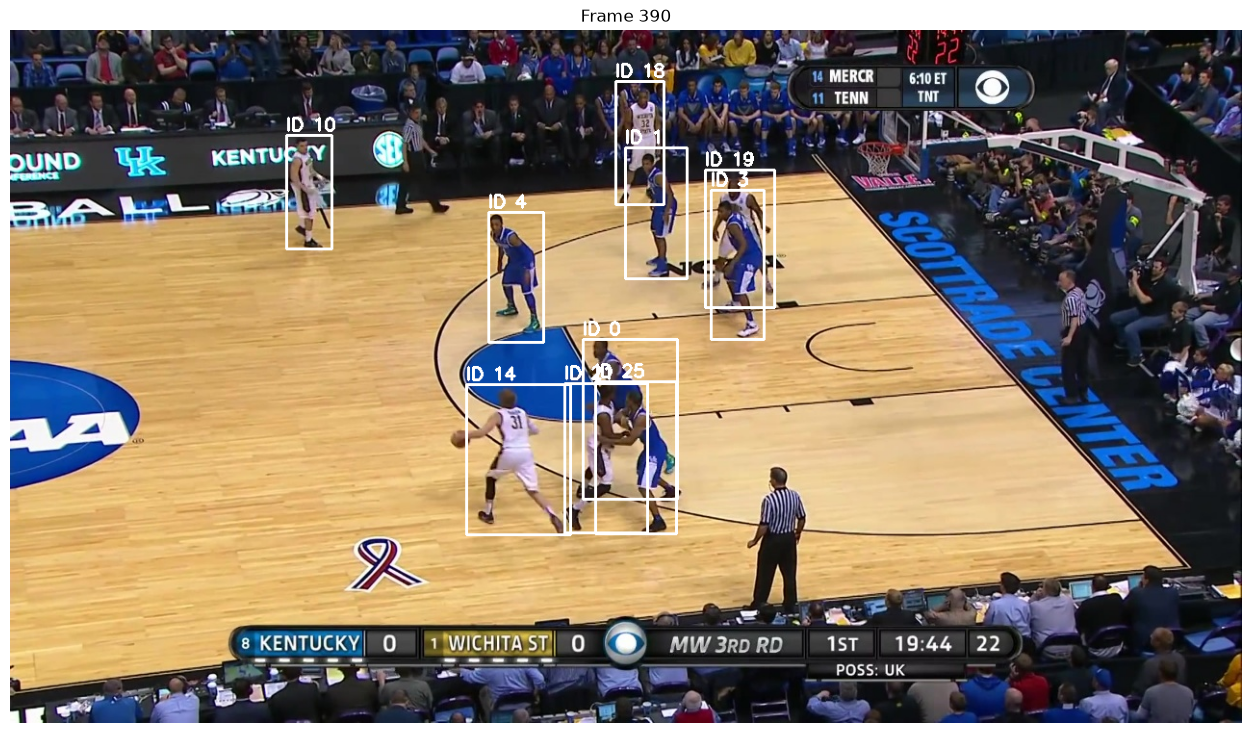

In [80]:
show_tracking_frame(
    390,
    tracks_df
)

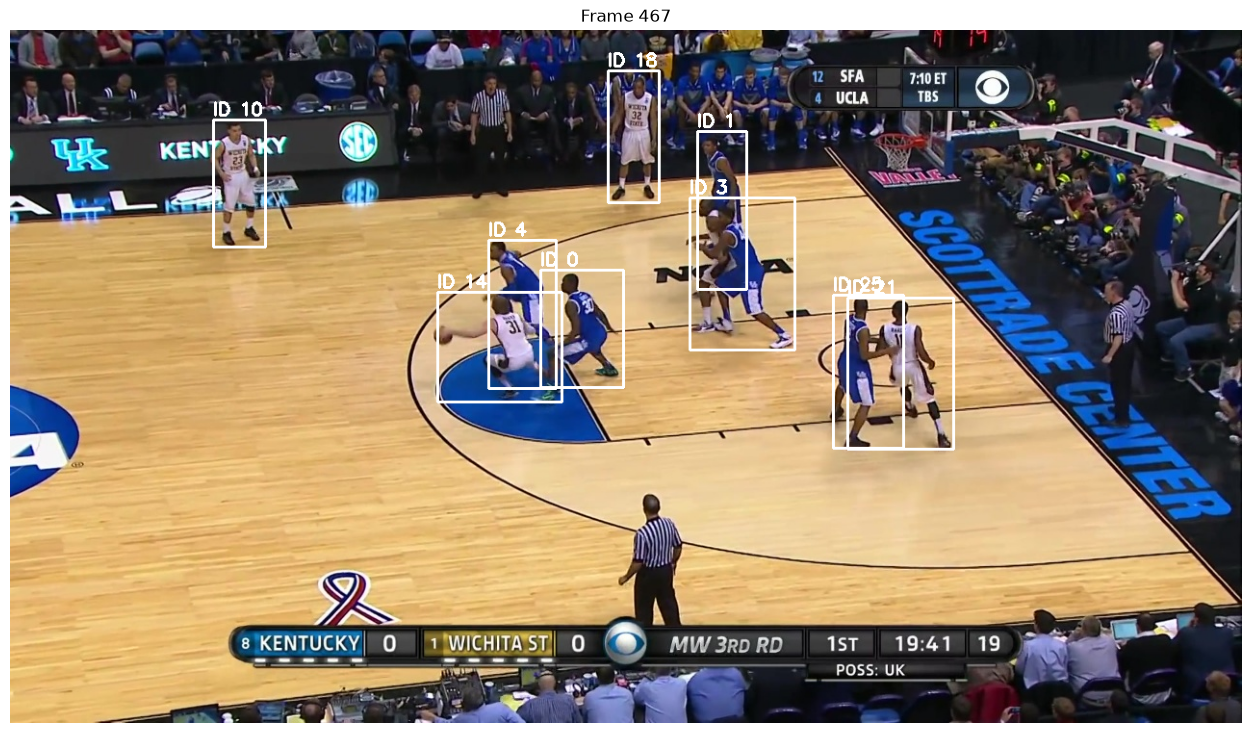

In [81]:
show_tracking_frame(
    467,
    tracks_df
)

Visualizzazione Id nel tempo

In [82]:
def show_track_samples(
    track_id,
    tracks_df,
    n_samples=16
):

    track_data = (
        tracks_df[
            tracks_df["track_id"]
            == track_id
        ]
        .sort_values(
            "frame"
        )
    )

    if len(track_data) == 0:

        print(
            "Track not found:",
            track_id
        )

        return

    indices = np.linspace(
        0,
        len(track_data) - 1,
        min(
            n_samples,
            len(track_data)
        )
    ).astype(int)

    samples = (
        track_data
        .iloc[
            indices
        ]
    )

    cols = 4

    rows = int(
        np.ceil(
            len(samples)
            / cols
        )
    )

    plt.figure(
        figsize=(
            12,
            rows * 4
        )
    )

    for i, (_, row) in enumerate(
        samples.iterrows()
    ):

        frame_number = int(
            row["frame"]
        )

        frame_path = (
            FRAMES_DIR
            / f"{frame_number:06d}.jpg"
        )

        frame = cv2.imread(
            str(frame_path)
        )

        if frame is None:
            continue

        x1 = max(
            0,
            int(row["x1"])
        )

        y1 = max(
            0,
            int(row["y1"])
        )

        x2 = min(
            frame.shape[1],
            int(row["x2"])
        )

        y2 = min(
            frame.shape[0],
            int(row["y2"])
        )

        crop = frame[
            y1:y2,
            x1:x2
        ]

        ax = plt.subplot(
            rows,
            cols,
            i + 1
        )

        if crop.size > 0:

            ax.imshow(
                cv2.cvtColor(
                    crop,
                    cv2.COLOR_BGR2RGB
                )
            )

        ax.set_title(
            f"ID {track_id}\n"
            f"frame {frame_number}"
        )

        ax.axis("off")

    plt.tight_layout()

    plt.show()

Controllo id problematici

In [83]:
display(
    track_summary.head(15)
)

,observations,first_frame,last_frame
track_id,,,
3,1155,1,1162
4,1141,1,1162
21,1011,145,1162
0,897,1,909
10,808,17,827
14,687,108,807
31,684,441,1162
18,658,127,790
1,639,1,649


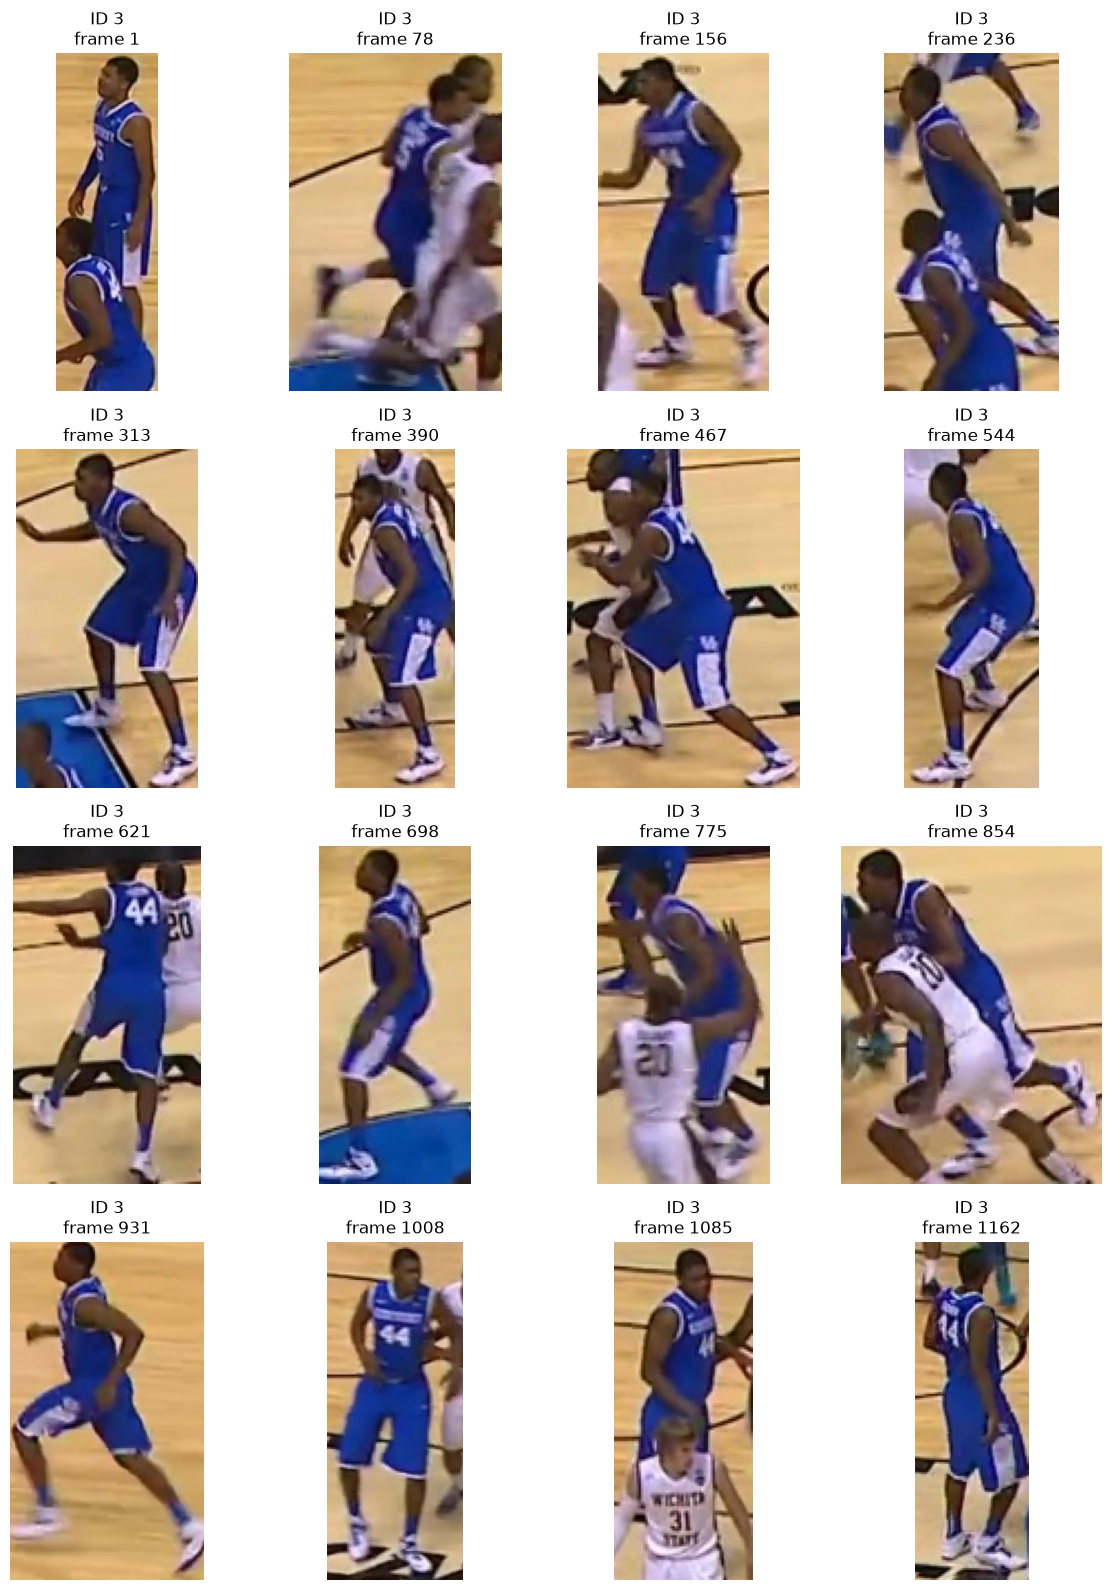

In [84]:
show_track_samples(
    track_id=3,
    tracks_df=tracks_df,
    n_samples=16
)

Caricamentto byteTrack baseline

In [85]:
BYTETRACK_CSV = (
    DRIVE_ROOT
    / "experiments"
    / "bytetrack_baseline"
    / f"{SEQUENCE_NAME}_tracks.csv"
)

bytetrack_df = pd.read_csv(
    BYTETRACK_CSV
)

print(
    "ByteTrack observations:",
    len(bytetrack_df)
)

print(
    "ByteTrack IDs:",
    bytetrack_df[
        "track_id"
    ].nunique()
)

print(
    "BoT-SORT observations:",
    len(tracks_df)
)

print(
    "BoT-SORT IDs:",
    tracks_df[
        "track_id"
    ].nunique()
)

ByteTrack observations: 10911
ByteTrack IDs: 27
BoT-SORT observations: 10888
BoT-SORT IDs: 34


In [86]:
comparison = pd.DataFrame({
    "tracker": [
        "ByteTrack",
        "BoT-SORT + ReID",
    ],
    "observations": [
        len(bytetrack_df),
        len(tracks_df),
    ],
    "unique_track_ids": [
        bytetrack_df[
            "track_id"
        ].nunique(),
        tracks_df[
            "track_id"
        ].nunique(),
    ],
})

display(
    comparison
)

,tracker,observations,unique_track_ids
0,ByteTrack,10911,27
1,BoT-SORT + ReID,10888,34


Ground Truth SportsMOT

In [87]:
GT_PATH = (
    DRIVE_ROOT
    / "datasets"
    / "sportsmot"
    / "val"
    / SEQUENCE_NAME
    / "gt"
    / "gt.txt"
)

print(
    GT_PATH
)

print(
    "Exists:",
    GT_PATH.exists()
)

/Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/datasets/sportsmot/val/v_00HRwkvvjtQ_c001/gt/gt.txt
Exists: True


Lettura Ground Thrth

In [88]:
gt_columns = [
    "frame",
    "gt_id",
    "x",
    "y",
    "w",
    "h",
    "confidence",
    "class",
    "visibility",
]

gt_df = pd.read_csv(
    GT_PATH,
    header=None
)

gt_df = gt_df.iloc[
    :,
    :len(gt_columns)
]

gt_df.columns = gt_columns[
    :gt_df.shape[1]
]

gt_df[
    "x1"
] = gt_df["x"]

gt_df[
    "y1"
] = gt_df["y"]

gt_df[
    "x2"
] = (
    gt_df["x"]
    + gt_df["w"]
)

gt_df[
    "y2"
] = (
    gt_df["y"]
    + gt_df["h"]
)

display(
    gt_df.head()
)

,frame,gt_id,x,y,w,h,confidence,class,visibility,x1,y1,x2,y2
0,1,0,438,269,118,169,1,1,1,438,269,556,438
1,1,1,973,389,78,216,1,1,1,973,389,1051,605
2,1,2,634,429,95,198,1,1,1,634,429,729,627
3,1,3,649,272,108,152,1,1,1,649,272,757,424
4,1,4,637,421,129,159,1,1,1,637,421,766,580


Controllo GT

In [89]:
print(
    "GT observations:",
    len(gt_df)
)

print(
    "GT IDs:",
    gt_df[
        "gt_id"
    ].nunique()
)

print(
    "GT frame range:",
    gt_df["frame"].min(),
    "→",
    gt_df["frame"].max()
)

GT observations: 11276
GT IDs: 10
GT frame range: 1 → 1162


Salvataggio Sumary

In [90]:
SUMMARY_CSV = (
    OUTPUT_DIR
    / f"{SEQUENCE_NAME}_track_summary.csv"
)

track_summary.to_csv(
    SUMMARY_CSV
)

print(
    "Saved:",
    SUMMARY_CSV
)

Saved: /Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/experiments/botsort_reid/v_00HRwkvvjtQ_c001_track_summary.csv
